Connected to base (Python 3.10.9)

In [105]:
"""
Modify Flockig algroithm for BlueSwarm

Algo from:
Reza Olfati-Saber,"Flocking for Multi-Agent Dynamic Systems:
Algorithms and Theory", IEEE TRANSACTIONS ON AUTOMATIC CONTROL, 
Vol. 51 (3), 3 Mar 2006

Created on July 02 2025
"""

import numpy as np

#%% Setup flocking hyperparameters
# ================================
a = 0.5
b = 0.5
c = np.divide(np.abs(a-b),np.sqrt(4*a*b)) 
eps = 0.1
h = 0.9
pi = np.pi
c1_a = 2
c2_a = 2*np.sqrt(2)
c1_b = 3
c2_b = 2*np.sqrt(3)
c1_g = 1
c2_g = 2*np.sqrt(1)

d = 260                       # lattice scale (distance between a-agents)
r = 1.2*d                   # interaction range of a-agents

def sigma_norm(z):   
    """
    define sigma_norm - differentiable everywhere
    Equation (8) in the paper.
    """ 
    norm_sig = (1/eps)*(np.sqrt(1+eps*np.linalg.norm(z)**2)-1)
    return norm_sig
    
def rho_h(z):
    """     
    A smooth bump function rho_h(z).
    Equation (10) in the paper.
    rho_h(z) = 
    1,                          if z ∈ [0,h]
    0.5(1 + cos(π(z-h)/(1-h))), if z ∈ [h,1]
    0,                          if z > 1
    """    
    if 0 <= z < h:
        rho_h = 1        
    elif h <= z < 1:
        rho_h = 0.5*(1+np.cos(pi*np.divide(z-h,1-h)))    
    else:
        rho_h = 0  
    return rho_h

def sigma_1(z):    
    """
    Defined after equation (15) in the paper.
    sigma_1(z) = z/√(1 + z^2)"""
    sigma_1 = np.divide(z,np.sqrt(1+z**2))    
    return sigma_1

def phi(z):    
    phi = 0.5*((a+b)*sigma_1(z+c)+(a-b))    
    return phi 


def phi_a(q_i, q_j, r_a, d_a): 
    z = sigma_norm(q_j-q_i)        
    phi_a = rho_h(z/r_a) * phi(z-d_a)    
    return phi_a
    
def n_ij(q_i, q_j):
    n_ij = np.divide(q_j-q_i,np.sqrt(1+eps*np.linalg.norm(q_j-q_i)**2))    
    return n_ij

def a_ij(q_i, q_j, r_a):        
    a_ij = rho_h(sigma_norm(q_j-q_i)/r_a)
    return a_ij

def b_ik(q_i, q_ik, d_b):        
    b_ik = rho_h(sigma_norm(q_ik-q_i)/d_b)
    return b_ik

def phi_b(q_i, q_ik, d_b): 
    z = sigma_norm(q_ik-q_i)        
    phi_b = rho_h(z/d_b) * (sigma_1(z-d_b)-1)    
    return phi_b

In [106]:
# from flock_fct import *

Restarted base (Python 3.10.9)

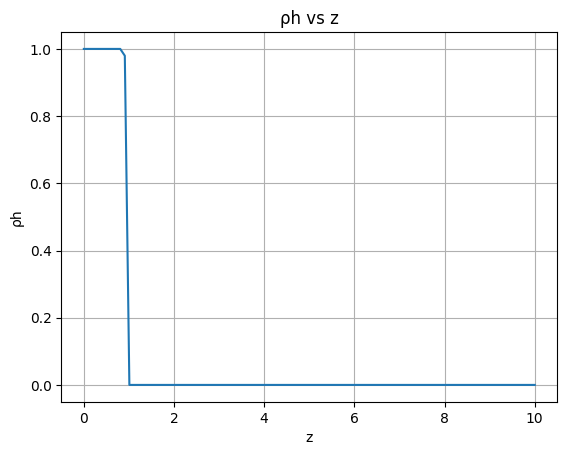

In [107]:
# %%
# %%
import numpy as np

import matplotlib.pyplot as plt

# Create z array (example range from 0 to 10)
z = np.linspace(0, 10, 100)

# Example function for rho_h (replace with your actual function)
rho_h_value =  np.array([rho_h(zi) for zi in z]) # This is just an example

# Create the plot
plt.figure()
plt.plot(z, rho_h_value)
plt.xlabel('z')
plt.ylabel('ρh')
plt.title('ρh vs z')
plt.grid(True)
plt.show()

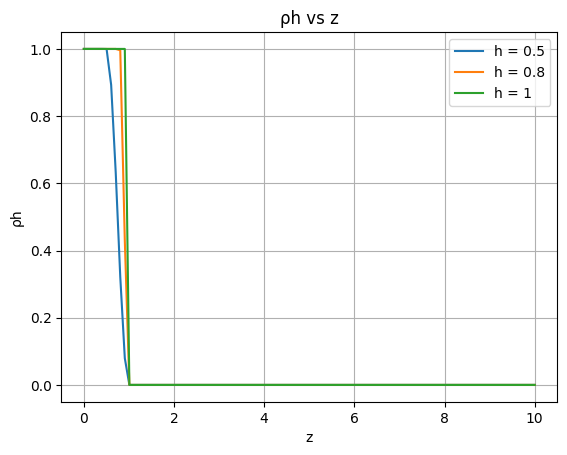

In [108]:
# %% plot ph_h
# %%
# %%
import numpy as np

import matplotlib.pyplot as plt

# Create z array (example range from 0 to 10)
z = np.linspace(0, 10, 100)
hi = [0.5, 0.8, 1]

# Create the plot
plt.figure()


for h in hi:# Example function for rho_h (replace with your actual function)

    rho_h_value =  np.array([rho_h(zi) for zi in z]) # This is just an example


    plt.plot(z, rho_h_value, label = f"h = {h}")

plt.legend()
plt.xlabel('z')
plt.ylabel('ρh')
plt.title('ρh vs z')
plt.grid(True)
plt.show()

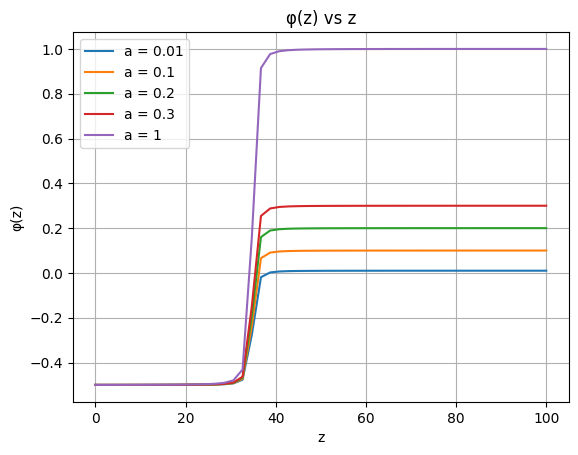

In [109]:
# %% plot phi
# Create z array (example range from -10 to 10)
z = np.linspace(0, 100, 50)

# hyperparameters

d = 2 * 13 # lattice scale (distance between a-agents)
r = 2 * d # interaction range of a-agents
r_a = sigma_norm(r)
d_a = sigma_norm(d)

# Create the plot
plt.figure()
for a in [0.01, 0.1, 0.2, 0.3, 1]:

    phi_values = np.array([phi(zi - d_a) for zi in z])
    plt.plot(z, phi_values, label = f"a = {a}")
plt.legend()

plt.xlabel('z')
plt.ylabel('φ(z)')
plt.title('φ(z) vs z')
plt.grid(True)
plt.show()

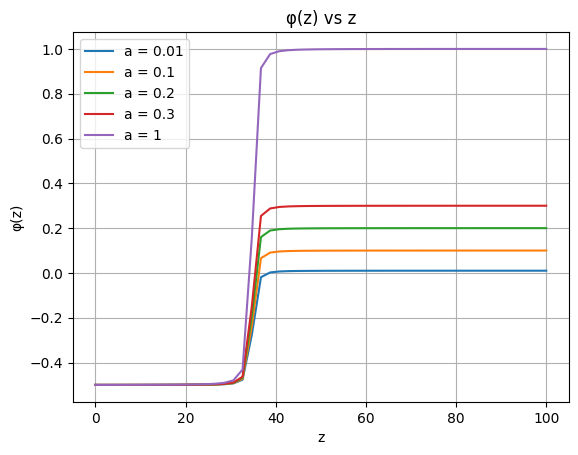

In [110]:
# %% plot phi
# Create z array (example range from -10 to 10)
z = np.linspace(0, 100, 50)

# hyperparameters

d = 2 * 13 # lattice scale (distance between a-agents)
r = 2 * d # interaction range of a-agents
r_a = sigma_norm(r)
d_a = sigma_norm(d)

# Create the plot
plt.figure()
for a in [0.01, 0.1, 0.2, 0.3, 1]:

    phi_values = np.array([phi(zi - d_a) for zi in z])
    plt.plot(z, phi_values, label = f"a = {a}")
plt.legend()

plt.xlabel('z')
plt.ylabel('φ(z)')
plt.title('φ(z) vs z')
plt.grid(True)
plt.show()

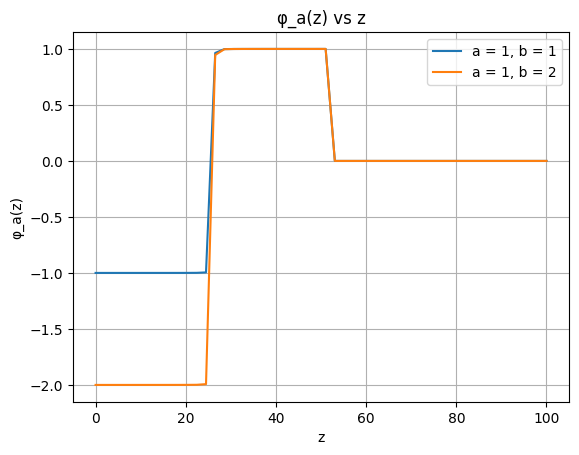

In [116]:
# %% plot phi_alpha


plt.figure()



for a in [1]:
    b = 1
    phi_a_values = np.array([phi_a(0, zi, r_a, d_a) for zi in z])
    plt.plot(z, phi_a_values, label = f"a = {a}, b = {b}")

    if a == 1:
        b = 2
        phi_a_values = np.array([phi_a(0, zi, r_a, d_a) for zi in z])
        plt.plot(z, phi_a_values, label = f"a = {a}, b = {b}")

    # phi_values = np.array([phi(zi - d_a) for zi in z])
    
plt.legend()

# phi_a_values = np.array([phi_a(0, zi, r_a, d_a) for zi in z])
# plt.plot(z, phi_a_values)
plt.xlabel('z')
plt.ylabel('φ_a(z)')
plt.title('φ_a(z) vs z')
plt.grid(True)
plt.show()

 d: 26, r: 52
with a eps of 0.1,  d_a: 72.82511696339463, r_a: 154.74222288168872
 d: 26, r: 52
with a eps of 0.2,  d_a: 53.35237784358064, r_a: 111.38298844762495
 d: 26, r: 52
with a eps of 1,  d_a: 25.019223662515376, r_a: 51.009614495783374
 d: 26, r: 52
with a eps of 10,  d_a: 8.122530024268686, r_a: 16.344147895224005


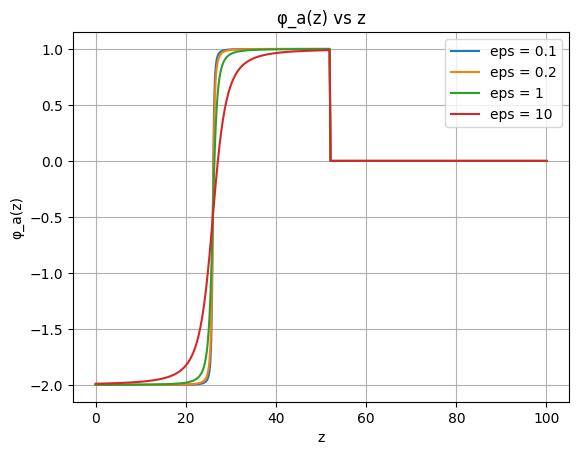

In [133]:
plt.figure()

z = np.linspace(0, 100, 500)

# print(f" d: {d}, r: {r}")

for eps in [0.1, 0.2, 1,10]:

    r_a = sigma_norm(r)
    d_a = sigma_norm(d)

    print(f" d: {d}, r: {r}")
    print(f"with a eps of {eps},  d_a: {d_a}, r_a: {r_a}")

    phi_a_values = np.array([phi_a(0, zi, r_a, d_a) for zi in z])
    plt.plot(z, phi_a_values, label = f"eps = {eps}")


    # phi_values = np.array([phi(zi - d_a) for zi in z])
    
plt.legend()

# phi_a_values = np.array([phi_a(0, zi, r_a, d_a) for zi in z])
# plt.plot(z, phi_a_values)
plt.xlabel('z')
plt.ylabel('φ_a(z)')
plt.title('φ_a(z) vs z')
plt.grid(True)
plt.show()